In [2]:
import pandas as pd

# Define the column names
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'Employment', 'InstallmentRate', 'PersonalStatusSex',
    'OtherDebtors', 'ResidenceDuration', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits', 'Job',
    'Liables', 'Telephone', 'ForeignWorker', 'Target'
]

# Load the .data file
df = pd.read_csv("german.data", sep=' ', header=None, names=columns)

# Save to CSV
df.to_csv("german_credit_data.csv", index=False)
print("CSV file saved as 'german_credit_data.csv'")


CSV file saved as 'german_credit_data.csv'


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load the CSV
df = pd.read_csv("german_credit_data.csv")

# Step 2: Encode categorical features
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Step 3: Features and Target
X = df.drop("Target", axis=1)
y = df["Target"]

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Model - Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 6: Predictions and Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.805

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.93      0.87       141
           2       0.75      0.51      0.61        59

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



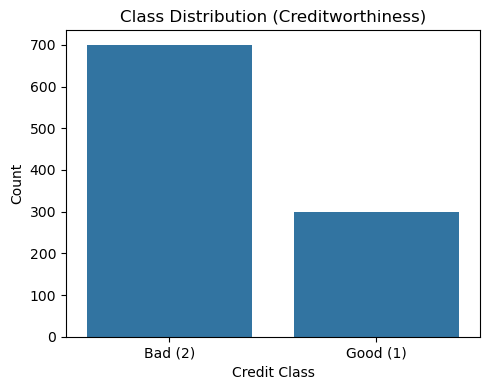

Accuracy: 0.805

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.93      0.87       141
           2       0.75      0.51      0.61        59

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200



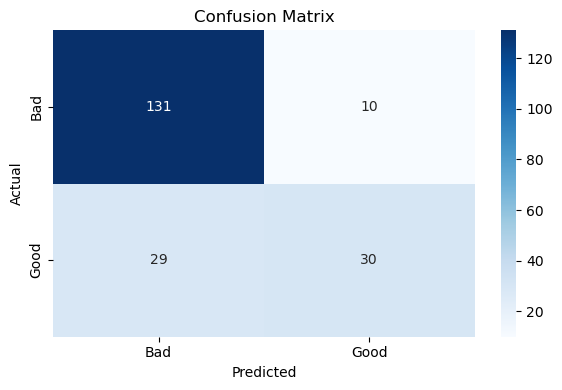

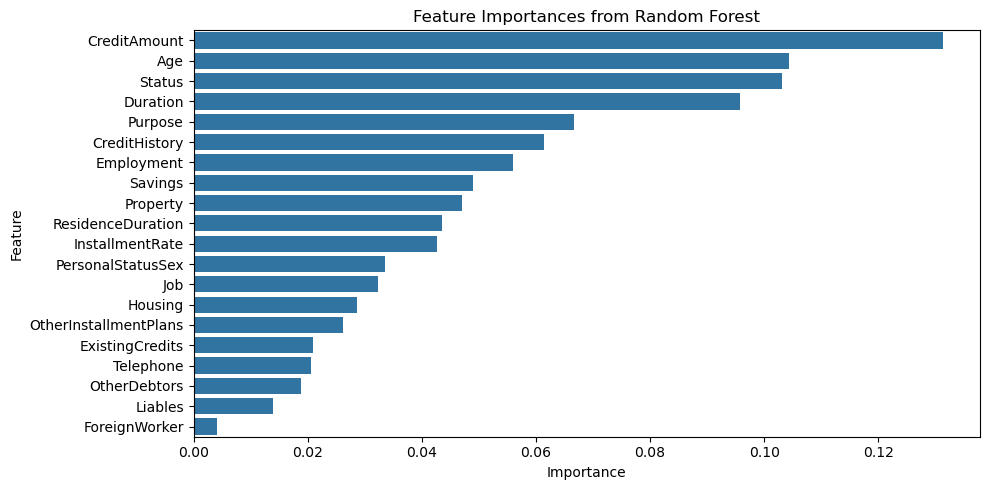

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load the CSV
df = pd.read_csv("german_credit_data.csv")

# Step 2: Encode categorical features
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Step 3: Plot class distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Target', data=df)
plt.title('Class Distribution (Creditworthiness)')
plt.xticks([0, 1], ['Bad (2)', 'Good (1)'])
plt.ylabel('Count')
plt.xlabel('Credit Class')
plt.tight_layout()
plt.show()

# Step 4: Features and Target
X = df.drop("Target", axis=1)
y = df["Target"]

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 7: Predictions and Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Step 9: Feature Importance
importances = model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Step 7: Predictions and Evaluation
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Optional: full report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy:  0.8050
Precision: 0.8187
Recall:    0.9291
F1 Score:  0.8704

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.93      0.87       141
           2       0.75      0.51      0.61        59

    accuracy                           0.81       200
   macro avg       0.78      0.72      0.74       200
weighted avg       0.80      0.81      0.79       200

